Dataset loaded!
Shape: (2129, 46)

Columns:
['b', 'e', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR', 'Unnamed: 9', 'LB', 'AC.1', 'FM.1', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'Unnamed: 31', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'Unnamed: 42', 'CLASS', 'Unnamed: 44', 'NSP']

Duplicate rows: 10
Shape after removing duplicates: (2118, 42)

Checking target: NSP
NSP found!

Target distribution:
NSP
1.0    1648
2.0     293
3.0     175
Name: count, dtype: int64

Target percentages:
NSP
1.0    77.88
2.0    13.85
3.0     8.27
Name: proportion, dtype: float64

Missing target values: 2

Features shape: (2116, 41)
Target shape: (2116,)

Non-numeric columns:
[]

Total missing feature values BEFORE: 0
Total missing feature values AFTER: 0

TRAIN / TEST SPLIT
------------------
X_train: (1692, 41)
X_test : (424, 41)
y_train: (1692,)
y_test : (424,)

Training classes:
NSP

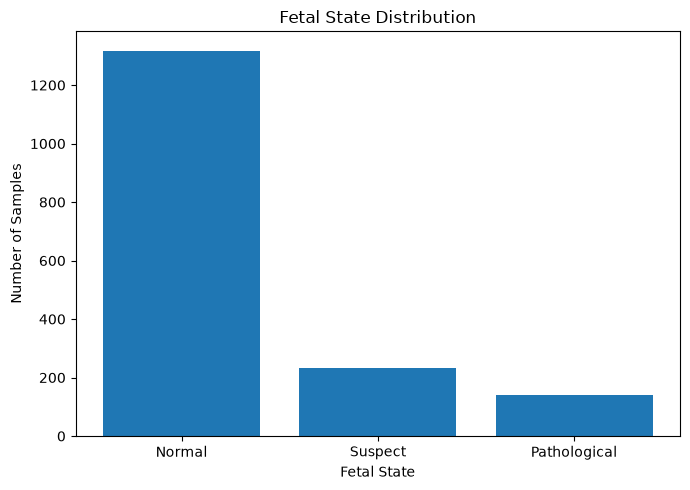

===== FEATURE STATISTICS =====
           count         mean         std    min          25%          50%          75%          max  missing
b         1692.0   886.953901  903.105303    0.0    44.000000   538.000000  1570.500000  3274.000000        0
e         1692.0  1712.294917  939.823124  287.0  1006.750000  1226.500000  2462.000000  3599.000000        0
AC        1692.0     2.712175    3.525428    0.0     0.000000     1.000000     4.000000    26.000000        0
FM        1692.0     7.906028   40.031848    0.0     0.000000     0.000000     2.000000   564.000000        0
UC        1692.0     3.676714    2.853630    0.0     1.000000     3.000000     5.000000    23.000000        0
DL        1692.0     1.536052    2.454651    0.0     0.000000     0.000000     2.000000    14.000000        0
DS        1692.0     0.003546    0.059461    0.0     0.000000     0.000000     0.000000     1.000000        0
DP        1692.0     0.128251    0.469766    0.0     0.000000     0.000000     0.000000  

In [3]:
# ============================================================
# CTG DATA - LOAD + PREPROCESS
# ============================================================

import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. FILE
# ------------------------------------------------------------

file_path = "../data/CTG.xls"

# ------------------------------------------------------------
# 2. LOAD DATA
# ------------------------------------------------------------
# The first row of the Data sheet is a title/header row.
# header=1 tells pandas to use the SECOND row as column names.

df = pd.read_excel(
    file_path,
    sheet_name="Data",
    header=1
)

print("Dataset loaded!")
print("Shape:", df.shape)

# ------------------------------------------------------------
# 3. CLEAN COLUMN NAMES
# ------------------------------------------------------------

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

print("\nColumns:")
print(df.columns.tolist())

# ------------------------------------------------------------
# 4. REMOVE COMPLETELY EMPTY ROWS/COLUMNS
# ------------------------------------------------------------

df = df.dropna(axis=0, how="all")
df = df.dropna(axis=1, how="all")

# ------------------------------------------------------------
# 5. REMOVE DUPLICATES
# ------------------------------------------------------------

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

# ------------------------------------------------------------
# 6. CHECK TARGET
# ------------------------------------------------------------

target = "NSP"

print("\nChecking target:", target)

if target not in df.columns:
    raise ValueError(
        f"NSP was not found.\nColumns available:\n{df.columns.tolist()}"
    )

print("NSP found!")

# ------------------------------------------------------------
# 7. TARGET DISTRIBUTION
# ------------------------------------------------------------

print("\nTarget distribution:")
print(df[target].value_counts().sort_index())

print("\nTarget percentages:")
print(
    (df[target].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

# ------------------------------------------------------------
# 8. REMOVE ROWS WITH MISSING TARGET
# ------------------------------------------------------------

print("\nMissing target values:", df[target].isnull().sum())

df = df.dropna(subset=[target]).reset_index(drop=True)

# ------------------------------------------------------------
# 9. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(columns=[target])
y = df[target]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)

# ------------------------------------------------------------
# 10. REMOVE NON-NUMERIC COLUMNS
# ------------------------------------------------------------

non_numeric = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("\nNon-numeric columns:")
print(non_numeric)

if non_numeric:
    X = X.drop(columns=non_numeric)

# ------------------------------------------------------------
# 11. HANDLE MISSING VALUES
# ------------------------------------------------------------

print("\nTotal missing feature values BEFORE:", X.isnull().sum().sum())

# Numerical median imputation
X = X.fillna(X.median())

print("Total missing feature values AFTER:", X.isnull().sum().sum())

# ------------------------------------------------------------
# 12. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTRAIN / TEST SPLIT")
print("------------------")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# ------------------------------------------------------------
# 13. CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\nTraining classes:")
print(y_train.value_counts().sort_index())

print("\nTesting classes:")
print(y_test.value_counts().sort_index())

# ------------------------------------------------------------
# 14. SAVE PROCESSED DATA
# ------------------------------------------------------------

processed_dir = "../data/processed"

os.makedirs(processed_dir, exist_ok=True)

X_train.to_csv(
    f"{processed_dir}/X_train.csv",
    index=False
)

X_test.to_csv(
    f"{processed_dir}/X_test.csv",
    index=False
)

y_train.to_csv(
    f"{processed_dir}/y_train.csv",
    index=False
)

y_test.to_csv(
    f"{processed_dir}/y_test.csv",
    index=False
)

print("\n======================================")
print("DATA + PREPROCESSING COMPLETE")
print("======================================")

print("\nSaved files:")
print("✓ data/processed/X_train.csv")
print("✓ data/processed/X_test.csv")
print("✓ data/processed/y_train.csv")
print("✓ data/processed/y_test.csv")

# ==========================================
# FINAL DATA ANALYSIS SUMMARY
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load processed datasets
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("===== DATASET SUMMARY =====")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Features         : {X_train.shape[1]}")

print("\n===== CLASS DISTRIBUTION =====")

class_counts = y_train.value_counts().sort_index()

class_names = {
    1: "Normal",
    2: "Suspect",
    3: "Pathological"
}

for cls, count in class_counts.items():
    percentage = count / len(y_train) * 100
    print(f"{class_names.get(int(cls), cls):15} : {count:4} ({percentage:.2f}%)")

print("\n===== MISSING VALUES =====")
print("Training:", X_train.isnull().sum().sum())
print("Testing :", X_test.isnull().sum().sum())

print("\n===== DUPLICATES =====")
print("Training duplicates:", X_train.duplicated().sum())
print("Testing duplicates :", X_test.duplicated().sum())

# ==========================================
# CLASS DISTRIBUTION PLOT
# ==========================================

plt.figure(figsize=(7, 5))

labels = ["Normal", "Suspect", "Pathological"]

plt.bar(
    labels,
    class_counts.values
)

plt.title("Fetal State Distribution")
plt.xlabel("Fetal State")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

# ==========================================
# FEATURE STATISTICS
# ==========================================

print("===== FEATURE STATISTICS =====")

stats = X_train.describe().T

stats["missing"] = X_train.isnull().sum()

print(stats.to_string())

In [4]:
print("===== FINAL FEATURE CHECK =====")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of features:", X_train.shape[1])

print("\nFeature columns:")
print(X_train.columns.tolist())

===== FINAL FEATURE CHECK =====
X_train shape: (1692, 41)
X_test shape : (424, 41)
Number of features: 41

Feature columns:
['b', 'e', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'DR', 'LB', 'AC.1', 'FM.1', 'UC.1', 'DL.1', 'DS.1', 'DP.1', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP', 'CLASS']
